**FASE 1:  LIBRARIES AND UPLOAD FILE**

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo gráfico
plt.style.use('seaborn-v0_8')
sns.set_palette('pastel')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Casino_Gaming_Data new.csv to Casino_Gaming_Data new.csv


In [3]:
# Cargar archivo
df = pd.read_csv("Casino_Gaming_Data new.csv")

# Visualizar las primeras filas
df.head()

,Fiscal Year,Month Ending,Licensee,Wagers,Patron Winnings,Cancelled Wagers,Online Casino Gaming Win/(Loss),Promotional Coupons or Credits Wagered (3),Promotional Deduction (4),Total Gross Gaming Revenue,Payment (5)
0,2021/22,06/30/2022 12:00:00 AM,Mohegan Tribe On-Reservation,379023,335505,5,43513,6390,6390,37123,6682
1,2021/22,06/30/2022 12:00:00 AM,MPTN On-Reservation,671843,685886,3,-14046,29041,0,-14046,0
2,2021/22,06/30/2022 12:00:00 AM,"MPI Master Wagering License CT, LLC",420056291,406814933,164727,13076631,12372142,3269158,9807473,1765345
3,2021/22,06/30/2022 12:00:00 AM,"Mohegan Digital, LLC",254393582,246515856,11645,7866081,1397441,1397441,6468640,1164355
4,2021/22,05/31/2022 12:00:00 AM,Mohegan Tribe On-Reservation,716607,681306,0,35301,4130,4130,31171,5611


**FASE 2: CLEANING AND DATA PREPROCESING**

In [4]:
# Revisión general
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Fiscal Year                                 143 non-null    object
 1   Month Ending                                143 non-null    object
 2   Licensee                                    143 non-null    object
 3   Wagers                                      143 non-null    int64 
 4   Patron Winnings                             143 non-null    int64 
 5   Cancelled Wagers                            143 non-null    int64 
 6   Online Casino Gaming Win/(Loss)             143 non-null    int64 
 7   Promotional Coupons or Credits Wagered (3)  143 non-null    int64 
 8   Promotional Deduction (4)                   143 non-null    int64 
 9   Total Gross Gaming Revenue                  143 non-null    int64 
 10  Payment (5)               

,Wagers,Patron Winnings,Cancelled Wagers,Online Casino Gaming Win/(Loss),Promotional Coupons or Credits Wagered (3),Promotional Deduction (4),Total Gross Gaming Revenue,Payment (5)
count,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02
mean,2.742207e+08,2.655218e+08,1.783408e+05,8.520509e+06,2.909760e+06,1.470359e+06,7.050150e+06,1.269229e+06
std,2.815530e+08,2.725166e+08,2.826004e+05,8.921912e+06,5.194974e+06,1.512958e+06,7.483596e+06,1.346855e+06
min,1.145280e+05,1.113650e+05,0.000000e+00,-8.099000e+04,0.000000e+00,0.000000e+00,-8.099000e+04,0.000000e+00
25%,1.407190e+06,1.357855e+06,5.000000e+00,3.713950e+04,1.118100e+04,6.188500e+03,3.172700e+04,5.711000e+03
50%,2.656540e+08,2.575127e+08,3.887000e+03,7.866081e+06,1.065100e+06,1.021521e+06,6.821088e+06,1.227796e+06
75%,5.352846e+08,5.156584e+08,2.913700e+05,1.587461e+07,3.844558e+06,3.071548e+06,1.304302e+07,2.347743e+06
max,7.838842e+08,7.573176e+08,1.133136e+06,2.570443e+07,3.220656e+07,4.163625e+06,2.281557e+07,4.106803e+06


The dataset contains 143 records with 11 columns. There are no null values, so imputation is not required. The data ranges from October 2021 to 2024.

Now the date is converted to datetime format to allow for time series analysis. Auxiliary columns such as Month, Year, and Date (yyyy-mm) were also created to manage the data easely.

In [7]:
# Convertir columna de fechas
df['Month Ending'] = pd.to_datetime(df['Month Ending'])

# Crear columnas útiles
df['Month'] = df['Month Ending'].dt.month
df['Year'] = df['Month Ending'].dt.year
df['Date'] = df['Month Ending'].dt.to_period('M').astype(str)

**DUPLICATE VERIFICATION**

In [8]:
# Verificación de duplicados
df.duplicated().sum()

np.int64(0)

**FASE 3:  BASIC METRICS**

Key metrics: Return to Player percentage, gross margin on wagers, and comparison between actual payout and estimated payout according to current regulations

In [9]:
# Pago esperado (18% del GGR)
df['Expected Payment'] = (df['Total Gross Gaming Revenue'] * 0.18).round()

# Porcentaje ganado por el casino
df['Payout Ratio'] = df['Patron Winnings'] / df['Wagers']

# Margen bruto sobre apuestas
df['GGR Margin'] = df['Total Gross Gaming Revenue'] / df['Wagers']

**Q1: Revenue Trends Analysis:**

*   How has the total gaming revenue changed over time?
*   Are there seasonal trends in casino revenue?



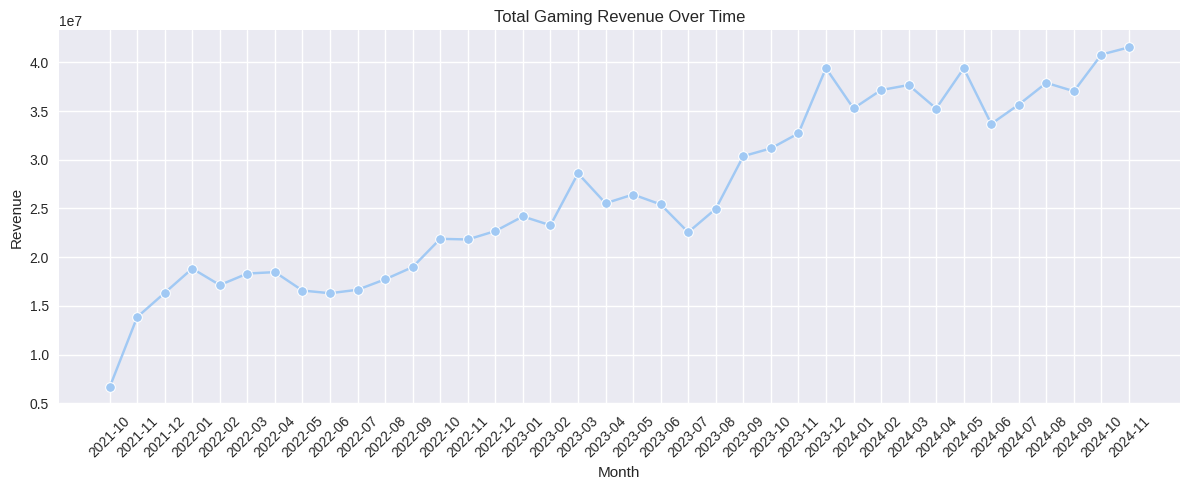

In [10]:
# Group by month and sum total revenue
monthly_revenue = df.groupby('Date')['Total Gross Gaming Revenue'].sum().reset_index()

# Plot
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_revenue, x='Date', y='Total Gross Gaming Revenue', marker='o')
plt.xticks(rotation=45)
plt.title('Total Gaming Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

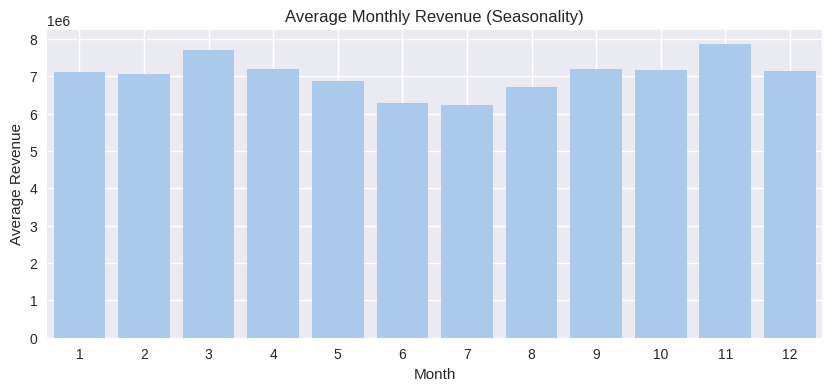

In [11]:
# Average revenue per calendar month
seasonal = df.groupby('Month')['Total Gross Gaming Revenue'].mean().reset_index()

# Plot
plt.figure(figsize=(10,4))
sns.barplot(data=seasonal, x='Month', y='Total Gross Gaming Revenue')
plt.title('Average Monthly Revenue (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.grid(True)
plt.show()

**Q2: Impact of Promotions:**

*   Do promotional credits and deductions lead to higher overall revenue?
*   Is there a correlation between promotional spending and net winnings?



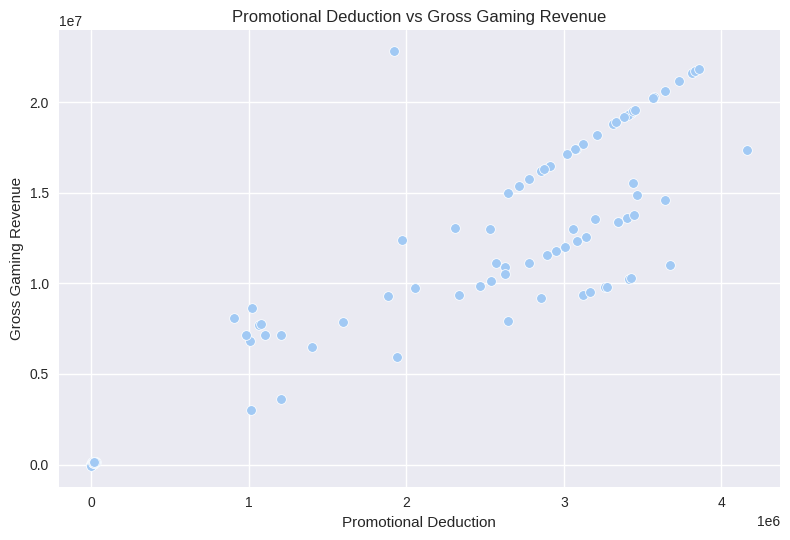

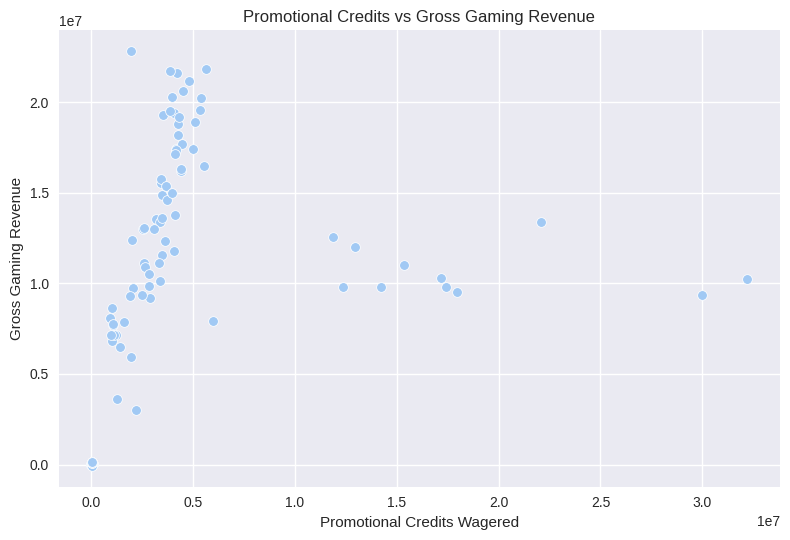

Correlation Matrix (rounded):
                                            Promotional Coupons or Credits Wagered (3)  \
Promotional Coupons or Credits Wagered (3)                                        1.00   
Promotional Deduction (4)                                                         0.62   
Total Gross Gaming Revenue                                                        0.44   

                                            Promotional Deduction (4)  \
Promotional Coupons or Credits Wagered (3)                       0.62   
Promotional Deduction (4)                                        1.00   
Total Gross Gaming Revenue                                       0.94   

                                            Total Gross Gaming Revenue  
Promotional Coupons or Credits Wagered (3)                        0.44  
Promotional Deduction (4)                                         0.94  
Total Gross Gaming Revenue                                        1.00  


In [14]:

# Load the dataset (if not already loaded)
df = pd.read_csv("Casino_Gaming_Data new.csv")  # Use the path where your file is stored

# Scatter Plot: Promotional Deduction vs Gross Revenue
sns.scatterplot(data=df,
                x='Promotional Deduction (4)',
                y='Total Gross Gaming Revenue')
plt.title('Promotional Deduction vs Gross Gaming Revenue')
plt.xlabel('Promotional Deduction')
plt.ylabel('Gross Gaming Revenue')
plt.tight_layout()
plt.show()

# Scatter Plot: Promotional Credits vs Gross Revenue
sns.scatterplot(data=df,
                x='Promotional Coupons or Credits Wagered (3)',
                y='Total Gross Gaming Revenue')
plt.title('Promotional Credits vs Gross Gaming Revenue')
plt.xlabel('Promotional Credits Wagered')
plt.ylabel('Gross Gaming Revenue')
plt.tight_layout()
plt.show()

# Correlation Matrix
correlation = df[['Promotional Coupons or Credits Wagered (3)',
                  'Promotional Deduction (4)',
                  'Total Gross Gaming Revenue']].corr()

# Display correlation values
print("Correlation Matrix (rounded):")
print(correlation.round(2))


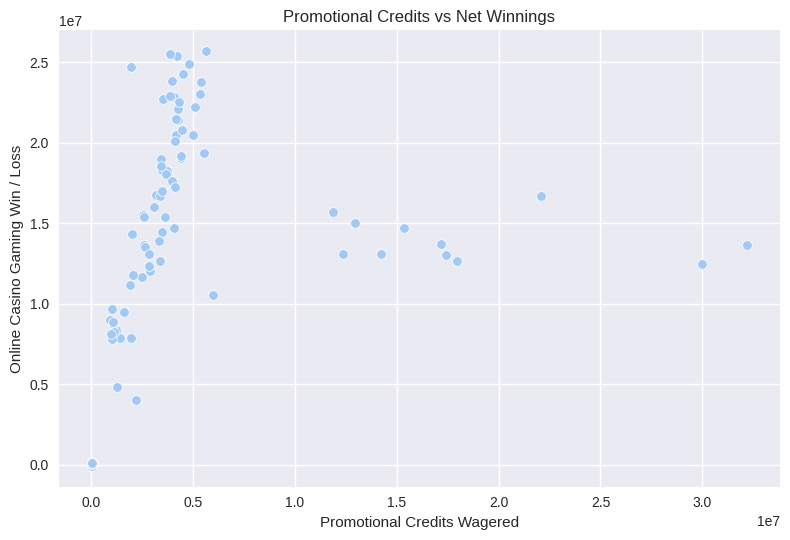

Correlation between promotional credits and net winnings:
                                            Promotional Coupons or Credits Wagered (3)  \
Promotional Coupons or Credits Wagered (3)                                        1.00   
Online Casino Gaming Win/(Loss)                                                   0.47   

                                            Online Casino Gaming Win/(Loss)  
Promotional Coupons or Credits Wagered (3)                             0.47  
Online Casino Gaming Win/(Loss)                                        1.00  


In [13]:
# Scatter plot: Promotional Credits Wagered vs Online Casino Gaming Win/(Loss)
sns.scatterplot(
    data=df,
    x='Promotional Coupons or Credits Wagered (3)',
    y='Online Casino Gaming Win/(Loss)'
)
plt.title('Promotional Credits vs Net Winnings')
plt.xlabel('Promotional Credits Wagered')
plt.ylabel('Online Casino Gaming Win / Loss')
plt.tight_layout()
plt.show()

# Correlation value between promo credits and win/loss
correlation = df[['Promotional Coupons or Credits Wagered (3)',
                  'Online Casino Gaming Win/(Loss)']].corr()

# Show correlation matrix rounded to 2 decimals
print("Correlation between promotional credits and net winnings:")
print(correlation.round(2))


Q3: Casino Performance Comparison
**texto en negrita**

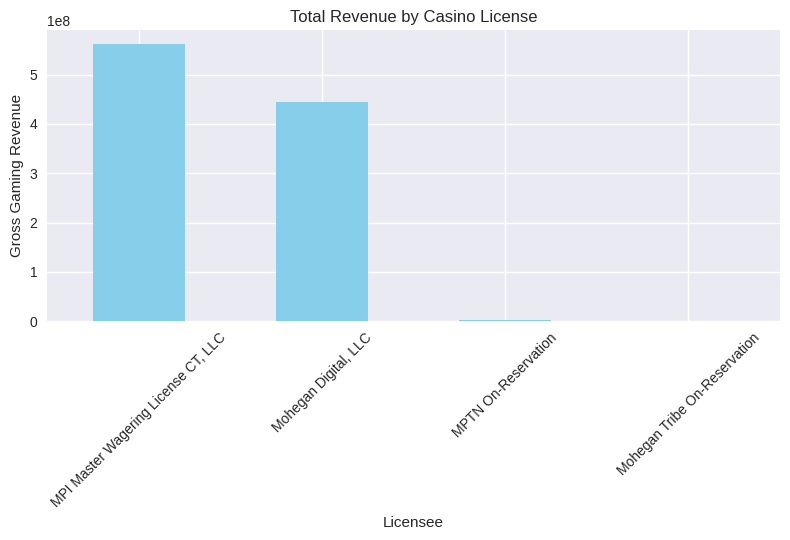

In [15]:
# Total revenue per licensee
total_by_license = df.groupby('Licensee')['Total Gross Gaming Revenue'].sum().sort_values(ascending=False)

# Bar chart to compare total revenue
total_by_license.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Casino License')
plt.ylabel('Gross Gaming Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-16-6b16045962bf>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month Ending'] = pd.to_datetime(df['Month Ending'])


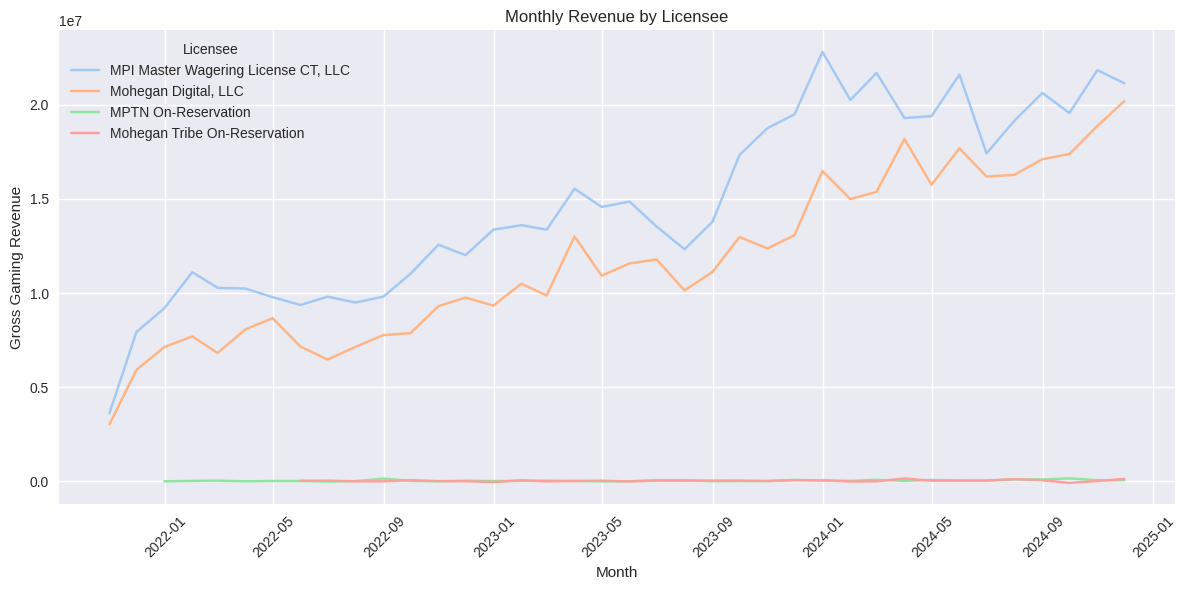

In [16]:
# Convert to datetime if needed
df['Month Ending'] = pd.to_datetime(df['Month Ending'])

# Group by month and license
monthly = df.groupby(['Month Ending', 'Licensee'])['Total Gross Gaming Revenue'].sum().reset_index()

# Line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='Month Ending', y='Total Gross Gaming Revenue', hue='Licensee')
plt.title('Monthly Revenue by Licensee')
plt.xlabel('Month')
plt.ylabel('Gross Gaming Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Answer: **



1.   PI Master Wagering License CT, LLC is the top-performing casino license with over $561 million in gross gaming revenue

2.   Mohegan Digital, LLC follows closely with $444 million

3. The two on-reservation licenses (MPTN and Mohegan Tribe) have significantly lower revenue, suggesting a smaller scale or later entry into the online market


**Q4: Wagering and Payout Patterns**

*   How do cancelled wagers impact revenue?
*   What percentage of wagers is typically returned as winnings?

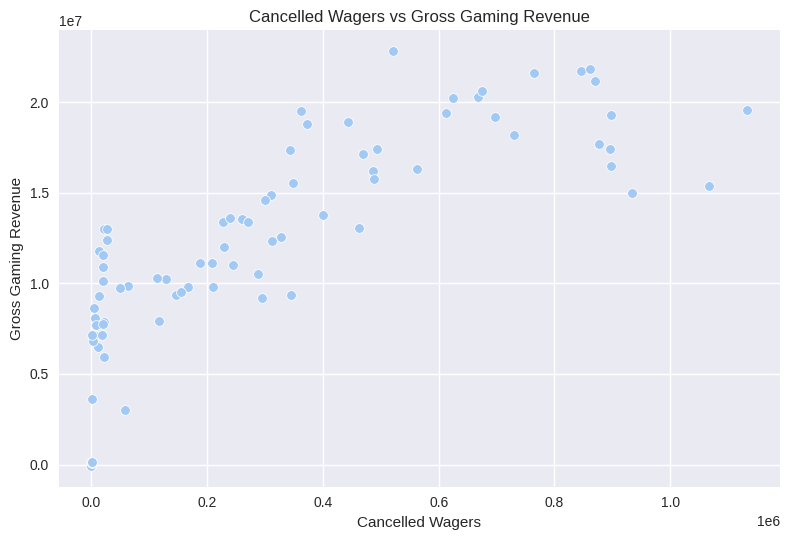

,Cancelled Wagers,Total Gross Gaming Revenue
Cancelled Wagers,1.00,0.83
Total Gross Gaming Revenue,0.83,1.00


In [17]:
# Scatter plot to visualize relationship
sns.scatterplot(data=df,
                x='Cancelled Wagers',
                y='Total Gross Gaming Revenue')
plt.title('Cancelled Wagers vs Gross Gaming Revenue')
plt.xlabel('Cancelled Wagers')
plt.ylabel('Gross Gaming Revenue')
plt.tight_layout()
plt.show()

# Correlation value
correlation_cancelled = df[['Cancelled Wagers', 'Total Gross Gaming Revenue']].corr()
correlation_cancelled.round(2)

How do cancelled wagers impact revenue?
Answer:
Cancelled wagers show a strong positive correlation with gross revenue.
This means that higher total revenue months tend to also have more cancelled wagers.
However, this does not mean cancellations increase revenue, but rather that they are more common when activity is higher overall.
In other words, cancelled wagers are not harmful, but a byproduct of increased wagering activity.



In [18]:
# Add new column for payout ratio
df['Payout Ratio'] = df['Patron Winnings'] / df['Wagers']

# Summary statistics
payout_stats = df['Payout Ratio'].describe().round(2)
payout_stats

,Payout Ratio
count,143.00
mean,0.97
std,0.02
min,0.89
25%,0.96
50%,0.97
75%,0.97
max,1.04


What percentage of wagers is typically returned as winnings?

answer:
To respond this, i'm using data statistic:

The average payout ratio is 97.0%, meaning that for every $100 wagered, approximately $97 is returned to players as winnings.


The lowest payout observed was 89%, while the highest reached 104%, indicating that in rare cases, players won more than they wagered.


The standard deviation is 2%, showing low variability and suggesting that payout behavior is very consistent across months and licensees.